## **0. Import Libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## **1. Get the Data**

In [2]:
# AI Human Data
it_ai_human_df = pd.read_csv('../data/it_ai_human_data.csv')
it_ai_human_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url             3750 non-null   str  
 1   source          3750 non-null   str  
 2   author          3750 non-null   str  
 3   publish_date    3750 non-null   str  
 4   text            5000 non-null   str  
 5   original_text   1250 non-null   str  
 6   generated_type  5000 non-null   str  
 7   label           5000 non-null   int64
dtypes: int64(1), str(7)
memory usage: 312.6 KB


In [3]:
it_ai_human_df.head()

,url,source,author,publish_date,text,original_text,generated_type,label
0,https://vietnamnet.vn/nen-mua-iphone-17e-gia-r...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-05,Sự xuất hiện của iPhone 17e đánh dấu bước tiếp...,NaN,human,0
1,NaN,NaN,NaN,NaN,"Trong Web3, khái niệm về danh tính đang được x...",NaN,generated,1
2,https://quantrimang.com/cong-nghe/cach-kiem-tr...,quantrimang,Dương Huyền Na,2026-06-25,**Hướng dẫn chi tiết cách kiểm tra phiên bản M...,Không chỉ riêng mình bạn mà nhiều người dùng k...,rewrited,1
3,https://vietnamnet.vn/hang-tram-trieu-iphone-c...,ictnews_vietnamnet,VietNamNet News; Hải Phong,2026-03-20,Một chiến dịch tấn công mạng tinh vi mới đang ...,NaN,human,0
4,https://quantrimang.com/cong-nghe/cach-su-dung...,quantrimang,Bá Điền,2026-04-01,Để có thể xem lại những bài viết đã đăng trên ...,Để xem lại tin Facebook đã đăng thì bạn cần ph...,rewrited,1


In [4]:
# Check duplicated text values
it_ai_human_df['text'].duplicated().sum()

np.int64(0)

In [5]:
# Check generated type value counts
it_ai_human_df['generated_type'].value_counts()

generated_type
human        2500
generated    1250
rewrited     1250
Name: count, dtype: int64

In [6]:
# Check source value counts
it_ai_human_df['source'].value_counts()

source
ictnews_vietnamnet    1676
quantrimang           1428
thanhnien_congnghe     236
vnexpress_sohoa        162
genk_recent            152
tuoitre_congnghe        96
Name: count, dtype: int64

In [7]:
# Check label value counts
it_ai_human_df['label'].value_counts()

label
0    2500
1    2500
Name: count, dtype: int64

## **2. Visualize the Data**

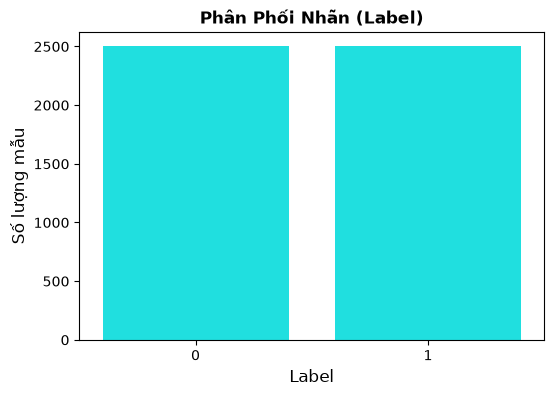

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=it_ai_human_df, x='label', color='aqua')
plt.title('Phân Phối Nhãn (Label)', fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Số lượng mẫu', fontsize=12)
plt.savefig('../figures/raw/label_distribution.png')
plt.show()

Như có thể thấy trên **biểu đồ phân phối nhãn**, tập dữ liệu đã được cân bằng giữa 2 lớp.

| Nhãn | Số lượng mẫu |
|:------|------------:|
| **Human** | 2,500 |
| **AI** | 2,500 |

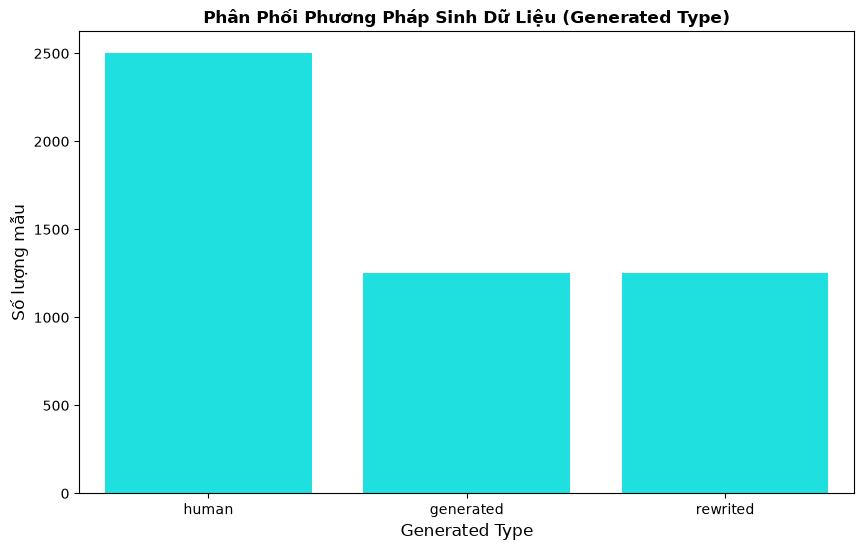

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=it_ai_human_df, x='generated_type', color='aqua')
plt.title('Phân Phối Phương Pháp Sinh Dữ Liệu (Generated Type)', fontweight='bold')
plt.xlabel('Generated Type', fontsize=12)
plt.ylabel('Số lượng mẫu', fontsize=12)
plt.savefig('../figures/raw/generated_type_distribution.png')
plt.show()

Ngoài ra, số lượng các mẫu dữ liệu được phân phối qua **phương pháp sinh dữ liệu** cũng đã được cân bằng dựa vào biểu đồ trên.
| Phương pháp sinh dữ liệu | Số lượng mẫu |
|:------|------------:|
| **Human** | 2,500 |
| **Generated**  | 1,250 |
| **Rewrited** | 1,250 |

**Ghi chú:**
- **Human**: Các bài báo, bài viết được thu thập từ các nguồn uy tín, có thông tin tác giả, ngày xuất bản rõ ràng.

- **Generated**: Các bài báo, bài viết do AI sinh ra từ đầu.

- **Rewrited**: Các bài báo, bài viết do AI viết, diễn đạt lại dựa trên văn bản gốc của con người.

In [10]:
# Create word_count for visualizing
it_ai_human_df['word_count'] = it_ai_human_df['text'].apply(lambda x: len(x))

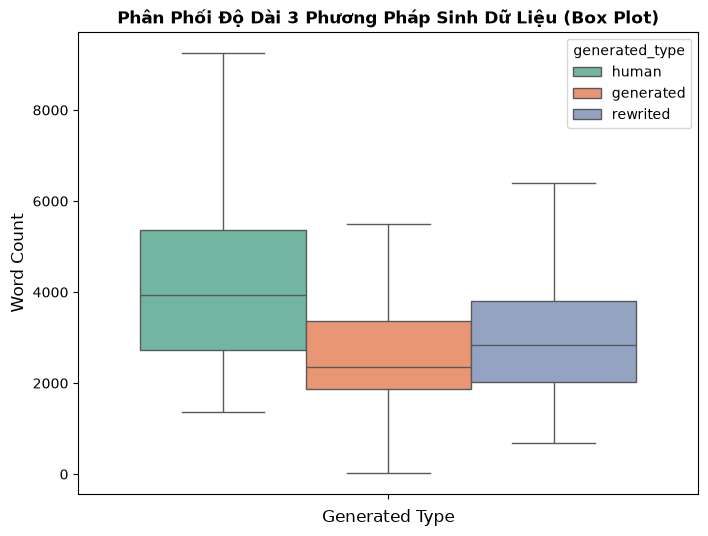

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=it_ai_human_df, hue='generated_type', y='word_count', palette='Set2', showfliers=False)
plt.title('Phân Phối Độ Dài 3 Phương Pháp Sinh Dữ Liệu (Box Plot)', fontweight='bold')
plt.xlabel('Generated Type', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.savefig('../figures/raw/generated_type_word_count_distribution_boxplot.png')
plt.show()

**Biểu đồ Box Plot** ở trên thể hiện phân phối số lượng từ dựa trên 3 phương pháp sinh dữ liệu gồm **Human**, **Generated** và **Rewrited**. Ở đây, ta rút ra một số ý quan trọng như sau: 

**1. Nhóm Human có độ dài văn bản lớn nhất**

Có thể thấy, giá trị trung vị của nhóm **Human** có giá trị khoảng **4,000 từ**, cao hơn đáng kể so với hai nhóm còn lại.

Ngoài ra:

- **Khoảng tứ phân vị (IQR)** có giá trị từ **khoảng 3,000 đến 5,500 từ** => Dữ liệu phân tán rộng, tức là độ dài **50%** văn bản nhóm **Human** rất đa dạng so với hai nhóm còn lại.

- **Khoảng phân bố của dữ liệu (Whiskers)** có các giá trị nằm trong phạm vi từ **1,500 đến 9,000 từ** => Điều này cho thấy độ dài văn bản không chỉ đa dạng ở phần lớn các mẫu có độ dài trung bình, mà còn cả các văn bản có độ dài ngắn hoặc dài hơn. Qua đó, dữ liệu phản ánh tốt hơn sự đa dạng của các bài viết trong thực tế.

**2. Nhóm Generated có độ dài văn bản ngắn nhất**

Giá trị trung vị của nhóm **Generated** có giá trị nhỏ nhất so với 2 nhóm còn lại, khoảng **2,200 từ**.

Bên cạnh đó:

- **Khoảng tứ phân vị (IQR)** lại hẹp hơn đáng kể so với 2 nhóm còn lại, **khoảng 2,000 - 3,800 từ** => Điều này cho thấy các văn bản do AI sinh ra thường có xu hướng ngắn và kém đa dạng hơn.

- **Giá trị lớn nhất** cũng chỉ dao động khoảng **5,800 từ**, thấp nhất so với 2 nhóm khác => Qua đó, ta thấy được hạn chế các văn bản do AI sinh ra, ít xuất hiện các bài viết có độ dài quá dài.

**3. Nhóm Rewrited có độ dài nằm giữa so với 2 nhóm còn lại**

In [12]:
# Show info of word counts of 3 generated types
summary = it_ai_human_df.groupby('generated_type')['word_count'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(2)
print(summary)

                count     mean  median      std   min    max
generated_type                                              
generated        1250  2646.75  2363.0  1125.58    31   7731
human            2500  4851.64  3945.5  3912.99  1357  44431
rewrited         1250  3157.66  2838.5  1822.50   691  23781


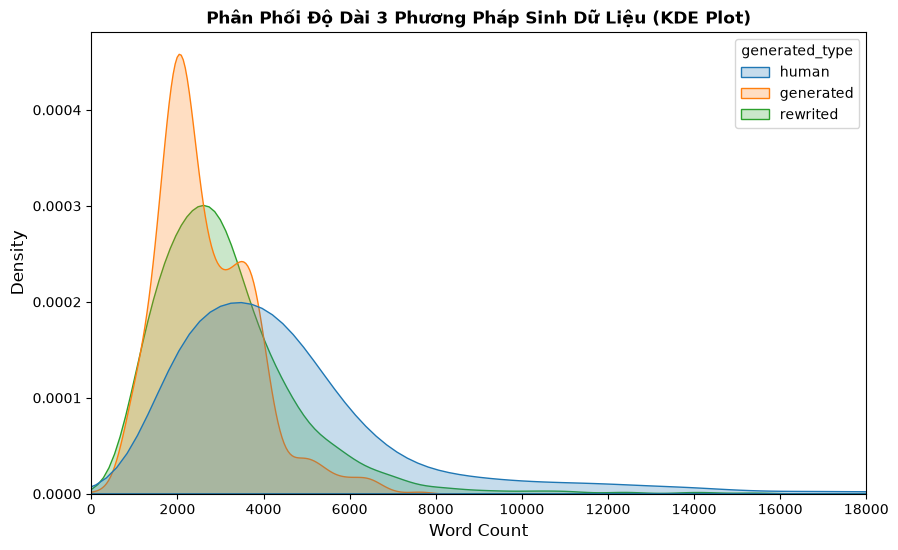

In [13]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=it_ai_human_df,
    x="word_count",
    hue="generated_type",
    fill=True,
    common_norm=False
)
plt.title('Phân Phối Độ Dài 3 Phương Pháp Sinh Dữ Liệu (KDE Plot)', fontweight='bold')
plt.xlim(0, 18000)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.savefig('../figures/raw/generated_type_word_count_distribution_kde_plot.png')
plt.show()

In [14]:
# Visualize published dates
published_date_df = it_ai_human_df[it_ai_human_df['generated_type'] == 'human'].copy()
published_date_df['publish_date'] = pd.to_datetime(published_date_df['publish_date'])

In [15]:
published_date_df['year'] = published_date_df['publish_date'].dt.year
# Count news each year
year_counts = published_date_df['year'].value_counts().sort_index().reset_index()

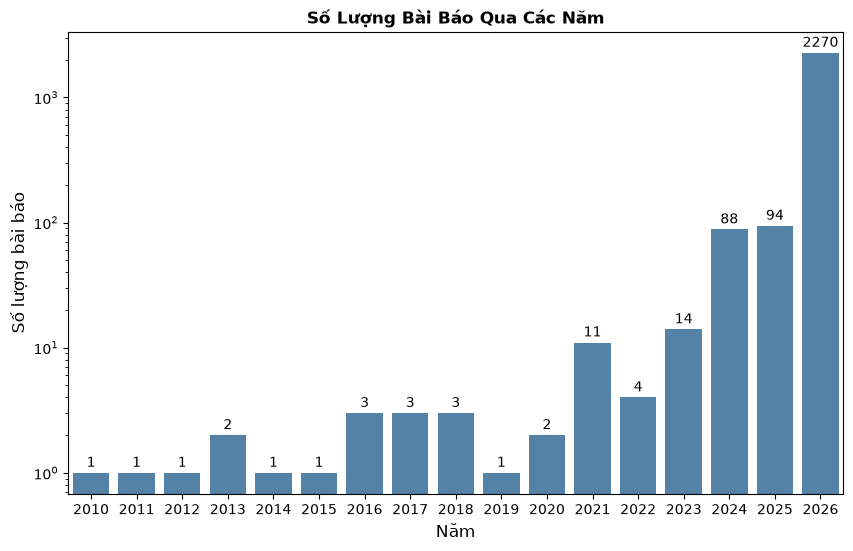

In [16]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=year_counts, x='year', y='count', color='steelblue')

# Display number of news in bar charts
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, padding=2)

plt.title('Số Lượng Bài Báo Qua Các Năm', fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Số lượng bài báo', fontsize=12)
plt.yscale('log')
plt.savefig('../figures/raw/number_news_each_year.png')
plt.show()